#### Notebook Setup

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/DAT255/voice-command-assistant")


for p in [
    PROJECT_ROOT/"notebooks",
    PROJECT_ROOT/"src",
    PROJECT_ROOT/"data/raw",
    PROJECT_ROOT/"data/processed",
    PROJECT_ROOT/"data/cache",
    PROJECT_ROOT/"models",
    PROJECT_ROOT/"results/figures",
    PROJECT_ROOT/"results/logs",
    PROJECT_ROOT/"reports",
]:
    p.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(PROJECT_ROOT/"data/cache/hf_home")
os.environ["HF_DATASETS_CACHE"] = str(PROJECT_ROOT/"data/cache/hf_datasets")
os.environ["TRANSFORMERS_CACHE"] = str(PROJECT_ROOT/"data/cache/transformers")


print("PROJECT_ROOT:", PROJECT_ROOT)
print("HF_HOME:", os.environ["HF_HOME"])

Mounted at /content/drive
INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.4/520.4 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 19.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully uninstalled dill-0.3.8
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.16
    Uninstalling multipr

# 02 — EDA & Preprocessing

This notebook covers:
- Loading the reproducible dataset index from Drive
- Basic EDA on labels and speakers
- Defining audio preprocessing targets (fixed length)
- Feature extraction plan (mel-spectrogram)

## 1. Setup + Load index + Sanity checks

#### Imports + versions (for reproducibility)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import datasets
import librosa

print("datasets version:", datasets.__version__)
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("librosa version:", librosa.__version__)

datasets version: 2.14.7
numpy version: 2.0.2
pandas version: 2.2.2
librosa version: 0.11.0


#### Load index.csv + quick checks

In [3]:
index_path = PROJECT_ROOT/"data/processed/index.csv"
index4_path = PROJECT_ROOT/"data/processed/index_4class.csv"

index_df = pd.read_csv(index_path)
index4_df = pd.read_csv(index4_path)

print("index_df:", index_df.shape)
print("index4_df:", index4_df.shape)

display(index_df.head(3))
display(index4_df.head(3))

required_cols = {
    "file","split","speaker_id","original_label_id","original_label_name",
    "target_label","target_id","is_unknown"
}
missing = required_cols - set(index_df.columns)
print("Missing columns:", missing)

index_df: (99720, 8)
index4_df: (15219, 8)


,file,split,speaker_id,original_label_id,original_label_name,target_label,target_id,is_unknown
0,backward/2356b88d_nohash_0.wav,train,2356b88d,30,backward,unknown,4,True
1,backward/3291330e_nohash_3.wav,train,3291330e,30,backward,unknown,4,True
2,backward/b91b718c_nohash_3.wav,train,b91b718c,30,backward,unknown,4,True


,file,split,speaker_id,original_label_id,original_label_name,target_label,target_id,is_unknown
0,down/2356b88d_nohash_0.wav,train,2356b88d,3,down,down,1,False
1,down/3291330e_nohash_3.wav,train,3291330e,3,down,down,1,False
2,down/43f57297_nohash_0.wav,train,43f57297,3,down,down,1,False


Missing columns: set()


#### Distribution checks from index (should match Notebook 01)

In [4]:
print("Rows per split:")
display(index_df["split"].value_counts())

print("\nTarget distribution (train only):")
train_dist = index_df[index_df["split"]=="train"]["target_label"].value_counts()
display(train_dist)

print("\nUnique speakers per split:")
display(index_df.groupby("split")["speaker_id"].nunique())

Rows per split:


,count
split,
train,84848
validation,9982
test,4890



Target distribution (train only):


,count
target_label,
unknown,72710
down,3134
left,3037
right,3019
up,2948



Unique speakers per split:


,speaker_id
split,
test,239
train,2112
validation,256


## 2. Audio loading & preprocessing policy

#### Load HF dataset (audio only, labels from index)

In [5]:
from datasets import load_dataset

ds = load_dataset("google/speech_commands", "v0.02")

print(ds)
print("Example keys:", ds["train"][0].keys())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/datasets/table.py:1421: FutureWarning: promote has been superseded by promote_options='default'.
  table = cls._concat_blocks(blocks, axis=0)


DatasetDict({
    train: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 84848
    })
    validation: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 9982
    })
    test: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 4890
    })
})
Example keys: dict_keys(['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'])


#### Define preprocessing config + helper functions

In [7]:
import numpy as np

SR = 16000
CLIP_SECONDS = 1.0
N_SAMPLES = int(SR * CLIP_SECONDS)

def pad_or_trim(x: np.ndarray, n_samples: int = N_SAMPLES) -> np.ndarray:
    """Pad with zeros or trim to exactly n_samples."""
    if len(x) < n_samples:
        pad_width = n_samples - len(x)
        x = np.pad(x, (0, pad_width), mode="constant")
    else:
        x = x[:n_samples]
    return x.astype(np.float32)

#### Pick a reproducible sample from index + load waveform from ds

In [8]:
sample_row = index_df[(index_df["split"]=="train") & (index_df["target_label"]!="unknown")].iloc[0]
sample_file = sample_row["file"]
print("Selected file:", sample_file)
print("Target label:", sample_row["target_label"], "Original:", sample_row["original_label_name"])

def find_by_file(split, file_path):
    files = ds[split]["file"]
    idx = files.index(file_path)
    return ds[split][idx]

ex = find_by_file("train", sample_file)
wave = ex["audio"]["array"]
sr = ex["audio"]["sampling_rate"]

print("Loaded sr:", sr, "len:", len(wave), "duration:", len(wave)/sr)
wave_fixed = pad_or_trim(wave)
print("Fixed len:", len(wave_fixed))

Selected file: down/2356b88d_nohash_0.wav
Target label: down Original: down
Loaded sr: 16000 len: 16000 duration: 1.0
Fixed len: 16000


#### Plot waveform + save to Drive

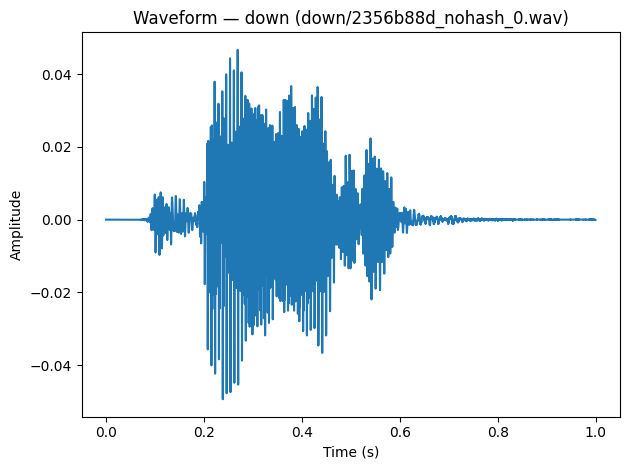

Saved: /content/drive/MyDrive/DAT255/voice-command-assistant/results/figures/waveform_example.png


In [9]:
import matplotlib.pyplot as plt

fig_dir = PROJECT_ROOT/"results/figures"
fig_dir.mkdir(parents=True, exist_ok=True)

t = np.arange(len(wave_fixed)) / SR

plt.figure()
plt.plot(t, wave_fixed)
plt.title(f"Waveform — {sample_row['target_label']} ({sample_file})")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()

wave_out = fig_dir/"waveform_example.png"
plt.savefig(wave_out, dpi=200)
plt.show()

print("Saved:", wave_out)

#### Compute mel-spectrogram + save figure

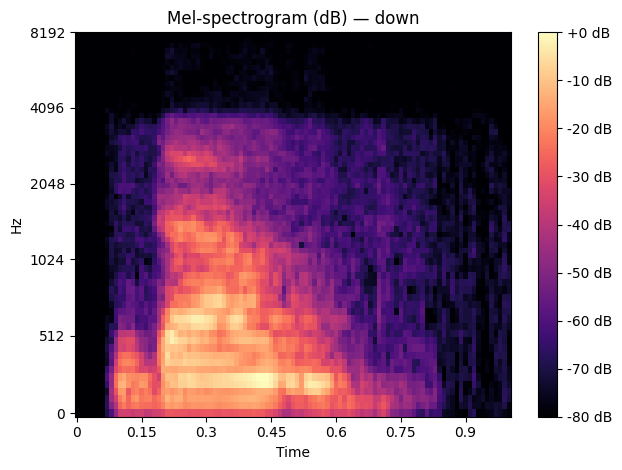

Saved: /content/drive/MyDrive/DAT255/voice-command-assistant/results/figures/mel_spectrogram_example.png
Mel shape: (64, 101)


In [10]:
import librosa
import librosa.display
import numpy as np

N_MELS = 64
HOP_LENGTH = 160
N_FFT = 400

S = librosa.feature.melspectrogram(
    y=wave_fixed,
    sr=SR,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    fmax=SR/2
)
S_db = librosa.power_to_db(S, ref=np.max)

plt.figure()
librosa.display.specshow(S_db, sr=SR, hop_length=HOP_LENGTH, x_axis="time", y_axis="mel")
plt.title(f"Mel-spectrogram (dB) — {sample_row['target_label']}")
plt.colorbar(format="%+2.0f dB")
plt.tight_layout()

mel_out = fig_dir/"mel_spectrogram_example.png"
plt.savefig(mel_out, dpi=200)
plt.show()

print("Saved:", mel_out)
print("Mel shape:", S_db.shape)

## 3. PyTorch Dataset for spectrogram-CNN

#### Dataset-klasse

In [11]:
import torch
from torch.utils.data import Dataset, DataLoader

class SpeechCommandsDataset(Dataset):
    def __init__(self, index_df, split="train", n_mels=64):
        self.df = index_df[index_df["split"] == split].reset_index(drop=True)
        self.n_mels = n_mels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = row["file"]
        target_id = row["target_id"]

        ex = find_by_file(row["split"], file_path)
        wave = ex["audio"]["array"]
        wave = pad_or_trim(wave)

        S = librosa.feature.melspectrogram(
            y=wave,
            sr=SR,
            n_fft=400,
            hop_length=160,
            n_mels=self.n_mels,
            fmax=SR/2
        )
        S_db = librosa.power_to_db(S, ref=np.max)

        X = torch.tensor(S_db).unsqueeze(0).float()  # (1, n_mels, time)
        y = torch.tensor(target_id).long()

        return X, y

#### Test dataset

In [12]:
train_dataset = SpeechCommandsDataset(index_df, split="train")
print("Train dataset size:", len(train_dataset))

X, y = train_dataset[0]
print("X shape:", X.shape)
print("y:", y)

Train dataset size: 84848
X shape: torch.Size([1, 64, 101])
y: tensor(4)


#### Test DataLoader

In [13]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

batch_X, batch_y = next(iter(train_loader))

print("Batch X shape:", batch_X.shape)
print("Batch y shape:", batch_y.shape)

Batch X shape: torch.Size([16, 1, 64, 101])
Batch y shape: torch.Size([16])


## 4. Efficient file lookup + dataset variants (4-class vs 5-class)

#### Build file → index lookup dict for each split

In [14]:
file_to_idx = {}
for split in ["train", "validation", "test"]:
    files = ds[split]["file"]
    file_to_idx[split] = {f: i for i, f in enumerate(files)}

def fast_find_by_file(split, file_path):
    i = file_to_idx[split].get(file_path, None)
    if i is None:
        raise KeyError(f"File not found in split={split}: {file_path}")
    return ds[split][i]

# Quick sanity
ex2 = fast_find_by_file("train", sample_file)
print("Sanity loaded:", ex2["file"])

Sanity loaded: down/2356b88d_nohash_0.wav


#### Update the Dataset class to use fast lookup

In [15]:
class SpeechCommandsDataset(Dataset):
    def __init__(self, index_df, split="train", n_mels=64, allowed_targets=None):
        df = index_df[index_df["split"] == split]
        if allowed_targets is not None:
            df = df[df["target_label"].isin(allowed_targets)]
        self.df = df.reset_index(drop=True)
        self.n_mels = n_mels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = row["file"]
        target_id = int(row["target_id"])

        ex = fast_find_by_file(row["split"], file_path)
        wave = ex["audio"]["array"]
        wave = pad_or_trim(wave)

        S = librosa.feature.melspectrogram(
            y=wave, sr=SR, n_fft=400, hop_length=160,
            n_mels=self.n_mels, fmax=SR/2
        )
        S_db = librosa.power_to_db(S, ref=np.max)

        X = torch.tensor(S_db).unsqueeze(0).float()
        y = torch.tensor(target_id).long()
        return X, y

#### Create datasets for 4-class and 5-class

In [16]:
FOUR_CLASS = {"up", "down", "left", "right"}
FIVE_CLASS = {"up", "down", "left", "right", "unknown"}

ds4_train = SpeechCommandsDataset(index_df, split="train", allowed_targets=FOUR_CLASS)
ds4_val   = SpeechCommandsDataset(index_df, split="validation", allowed_targets=FOUR_CLASS)
ds4_test  = SpeechCommandsDataset(index_df, split="test", allowed_targets=FOUR_CLASS)

ds5_train = SpeechCommandsDataset(index_df, split="train", allowed_targets=FIVE_CLASS)
ds5_val   = SpeechCommandsDataset(index_df, split="validation", allowed_targets=FIVE_CLASS)
ds5_test  = SpeechCommandsDataset(index_df, split="test", allowed_targets=FIVE_CLASS)

print("4-class sizes:", len(ds4_train), len(ds4_val), len(ds4_test))
print("5-class sizes:", len(ds5_train), len(ds5_val), len(ds5_test))

4-class sizes: 12138 1442 1639
5-class sizes: 84848 9982 4890


#### Test DataLoader speed + shapes

In [17]:
loader4 = DataLoader(ds4_train, batch_size=16, shuffle=True, num_workers=2)
Xb, yb = next(iter(loader4))
print("4-class batch:", Xb.shape, yb.shape, "labels example:", yb[:10].tolist())

loader5 = DataLoader(ds5_train, batch_size=16, shuffle=True, num_workers=2)
Xb, yb = next(iter(loader5))
print("5-class batch:", Xb.shape, yb.shape, "labels example:", yb[:10].tolist())

4-class batch: torch.Size([16, 1, 64, 101]) torch.Size([16]) labels example: [0, 0, 0, 0, 2, 1, 0, 2, 1, 0]
5-class batch: torch.Size([16, 1, 64, 101]) torch.Size([16]) labels example: [4, 1, 4, 4, 4, 4, 4, 4, 4, 4]
